## Step 9 — Model Evaluation on Test Set

In [18]:
# Evaluating the model on the unseen test set and running 5-fold cross validation.

best_model = model
best_name  = 'Linear Regression'
test_preds = best_model.predict(X_test_s)

mae_t  = mean_absolute_error(y_test, test_preds)
rmse_t = np.sqrt(mean_squared_error(y_test, test_preds))
r2_t   = r2_score(y_test, test_preds)

print('-- TEST SET METRICS --')
print(f'   MAE  : {mae_t:.2f}')
print(f'   RMSE : {rmse_t:.2f}')
print(f'   R2   : {r2_t:.4f}')

cv_scores = cross_val_score(best_model, X_train_s, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'\n-- 5-FOLD CROSS VALIDATION --')
print(f'   CV R2 per fold : {[round(s, 4) for s in cv_scores]}')
print(f'   Mean CV R2     : {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}')

-- TEST SET METRICS --
   MAE  : 45.69
   RMSE : 57.21
   R2   : 0.7217

-- 5-FOLD CROSS VALIDATION --
   CV R2 per fold : [np.float64(0.723), np.float64(0.7144), np.float64(0.7214), np.float64(0.7254), np.float64(0.7239)]
   Mean CV R2     : 0.7216 +/- 0.0038


## Step 10 — Result Visualisations

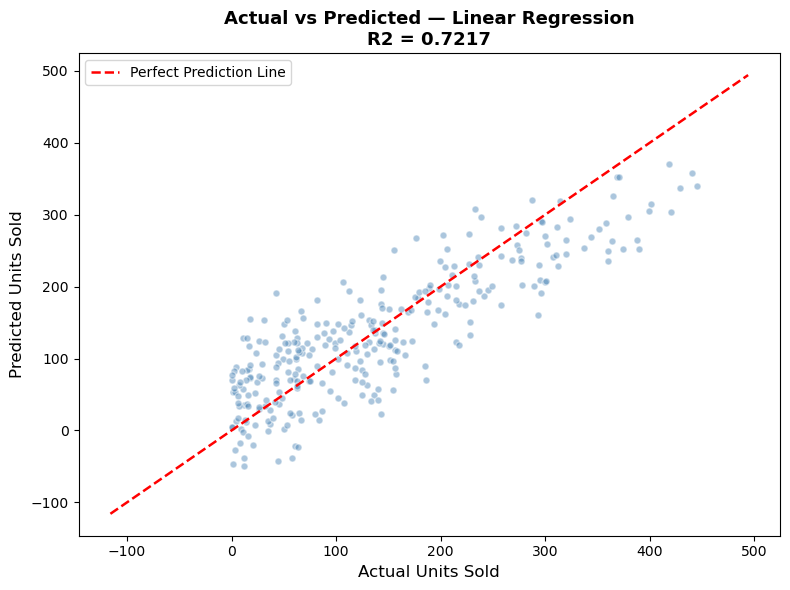

In [19]:
# Scatter plot of actual vs predicted values. Points near the red line mean accurate predictions.

sample = min(300, len(y_test))
idx    = np.random.choice(len(y_test), sample, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test.iloc[idx], test_preds[idx],
           alpha=0.45, color='steelblue', edgecolors='white', s=25)
lims = [min(y_test.min(), test_preds.min()), max(y_test.max(), test_preds.max())]
ax.plot(lims, lims, 'r--', linewidth=1.8, label='Perfect Prediction Line')
ax.set_xlabel('Actual Units Sold', fontsize=12)
ax.set_ylabel('Predicted Units Sold', fontsize=12)
ax.set_title(f'Actual vs Predicted — {best_name}\nR2 = {r2_t:.4f}', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

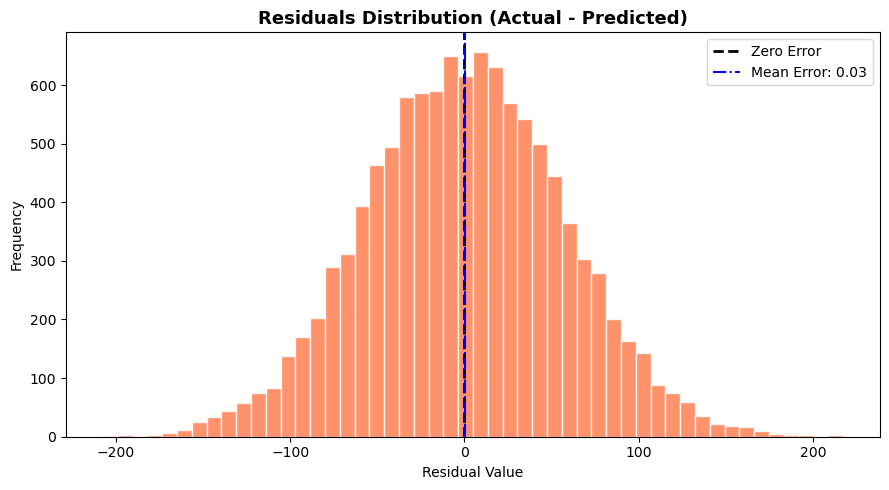

In [20]:
# Residuals distribution — should be centred near 0 for a well-fitted model.

residuals = y_test.values - test_preds

plt.figure(figsize=(9, 5))
plt.hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.85)
plt.axvline(0, color='black', linewidth=2, linestyle='--', label='Zero Error')
plt.axvline(residuals.mean(), color='blue', linewidth=1.5, linestyle='-.',
            label=f'Mean Error: {residuals.mean():.2f}')
plt.title('Residuals Distribution (Actual - Predicted)', fontsize=13, fontweight='bold')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

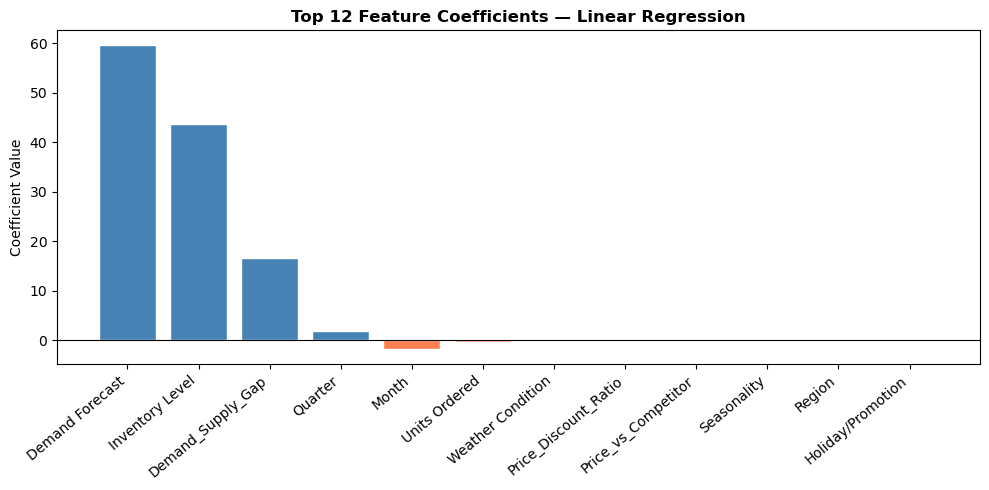

In [21]:
# Bar chart of top 12 feature coefficients. Blue = positive effect, Red = negative effect.

coefs        = pd.Series(best_model.coef_, index=FEATURES)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(12)
bar_colors   = ['steelblue' if c > 0 else 'coral' for c in coefs_sorted]

plt.figure(figsize=(10, 5))
plt.bar(coefs_sorted.index, coefs_sorted.values, color=bar_colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Top 12 Feature Coefficients — Linear Regression', fontsize=12, fontweight='bold')
plt.ylabel('Coefficient Value')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

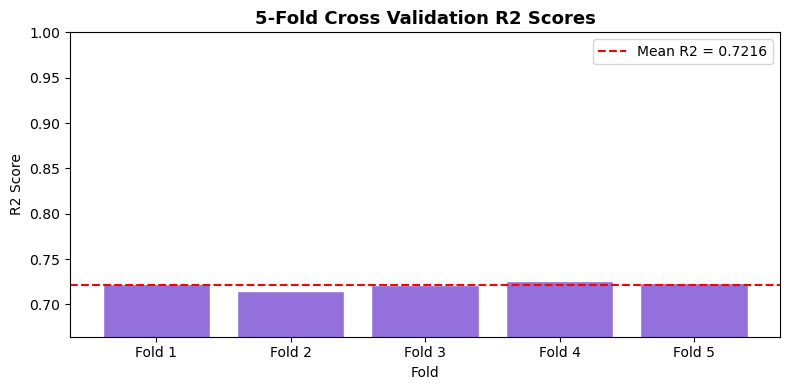

In [22]:
# R2 score per cross-validation fold — consistent scores mean the model generalises well.

plt.figure(figsize=(8, 4))
plt.bar([f'Fold {i+1}' for i in range(len(cv_scores))],
        cv_scores, color='mediumpurple', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean R2 = {cv_scores.mean():.4f}')
plt.ylim(max(0, cv_scores.min() - 0.05), 1.0)
plt.title('5-Fold Cross Validation R2 Scores', fontsize=13, fontweight='bold')
plt.ylabel('R2 Score')
plt.xlabel('Fold')
plt.legend()
plt.tight_layout()
plt.show()

## Step 11 — Save Trained Model

In [23]:
# Saving the trained model and scaler to disk so the Gradio frontend can load them.

joblib.dump(best_model, 'demand_forecast_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(FEATURES,   'features.pkl')

print('Saved: demand_forecast_model.pkl')
print('Saved: scaler.pkl')
print('Saved: features.pkl')

Saved: demand_forecast_model.pkl
Saved: scaler.pkl
Saved: features.pkl


## Step 12 — Gradio Frontend

In [24]:
# Installing Gradio if not already installed.

!pip install gradio

In [25]:
# Building and launching the Gradio frontend for the trained model.
# Users fill in product and store details and get an instant demand prediction.

import gradio as gr

# Label encoding mappings — must match what was used during training
category_map    = {'Clothing': 0, 'Electronics': 1, 'Furniture': 2, 'Groceries': 3, 'Toys': 4}
region_map      = {'East': 0, 'North': 1, 'South': 2, 'West': 3}
weather_map     = {'Cloudy': 0, 'Rainy': 1, 'Snowy': 2, 'Sunny': 3}
seasonality_map = {'Autumn': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}

def predict_demand(category, region, inventory_level, units_ordered,
                   demand_forecast, price, discount, weather,
                   holiday_promotion, competitor_pricing, seasonality,
                   month, day_of_week, quarter):

    # Encode categorical inputs and compute engineered features
    holiday_encoded      = 1 if holiday_promotion == 'Yes' else 0
    demand_supply_gap    = demand_forecast - inventory_level
    price_discount_ratio = price / (discount + 1)
    price_vs_competitor  = price - competitor_pricing

    input_data = {
        'Category':              category_map[category],
        'Region':                region_map[region],
        'Inventory Level':       inventory_level,
        'Units Ordered':         units_ordered,
        'Demand Forecast':       demand_forecast,
        'Price':                 price,
        'Discount':              discount,
        'Weather Condition':     weather_map[weather],
        'Holiday/Promotion':     holiday_encoded,
        'Competitor Pricing':    competitor_pricing,
        'Seasonality':           seasonality_map[seasonality],
        'Month':                 month,
        'DayOfWeek':             day_of_week,
        'Quarter':               quarter,
        'Demand_Supply_Gap':     demand_supply_gap,
        'Price_Discount_Ratio':  price_discount_ratio,
        'Price_vs_Competitor':   price_vs_competitor,
    }

    input_df     = pd.DataFrame([input_data])[FEATURES]
    input_scaled = scaler.transform(input_df)
    prediction   = best_model.predict(input_scaled)[0]
    prediction   = max(0, round(prediction))

    return (
        f"{prediction} units",
        f"{demand_supply_gap:.1f}",
        f"{'Higher' if price_vs_competitor > 0 else 'Lower'} by {abs(price_vs_competitor):.2f}",
        f"{price_discount_ratio:.2f}"
    )


with gr.Blocks(title='Retail Demand Forecasting', theme=gr.themes.Soft()) as app:

    gr.Markdown("""
    # Retail Demand Forecasting
    ### AI-Powered Sales Prediction · Intel VUIP111 Major Project
    Fill in the product and store details below to predict how many units will be sold.
    ---
    """)

    with gr.Row():

        with gr.Column():
            gr.Markdown('### Store & Product Info')
            category        = gr.Dropdown(choices=list(category_map.keys()), label='Product Category', value='Groceries')
            region          = gr.Dropdown(choices=list(region_map.keys()), label='Store Region', value='North')
            inventory_level = gr.Slider(minimum=50, maximum=500, value=250, step=1, label='Inventory Level (units in stock)')
            units_ordered   = gr.Slider(minimum=20, maximum=200, value=80, step=1, label='Units Ordered from Supplier')
            demand_forecast = gr.Number(value=130.0, label='Demand Forecast (system estimate)')

        with gr.Column():
            gr.Markdown('### Pricing & Conditions')
            price              = gr.Slider(minimum=10.0, maximum=100.0, value=45.0, step=0.5, label='Selling Price ($)')
            discount           = gr.Slider(minimum=0, maximum=20, value=10, step=5, label='Discount (%)')
            competitor_pricing = gr.Number(value=42.0, label='Competitor Price ($)')
            weather            = gr.Dropdown(choices=list(weather_map.keys()), label='Weather Condition', value='Sunny')
            holiday_promotion  = gr.Radio(choices=['Yes', 'No'], label='Holiday / Promotion Active?', value='No')

        with gr.Column():
            gr.Markdown('### Time & Season')
            seasonality = gr.Dropdown(choices=list(seasonality_map.keys()), label='Season', value='Summer')
            month       = gr.Slider(minimum=1, maximum=12, value=6, step=1, label='Month (1=Jan, 12=Dec)')
            day_of_week = gr.Slider(minimum=0, maximum=6, value=2, step=1, label='Day of Week (0=Mon, 6=Sun)')
            quarter     = gr.Slider(minimum=1, maximum=4, value=2, step=1, label='Quarter (1-4)')

    gr.Markdown('---')
    predict_btn = gr.Button('Predict Demand', variant='primary', size='lg')
    gr.Markdown('### Prediction Results')

    with gr.Row():
        prediction_out     = gr.Textbox(label='Predicted Units Sold')
        demand_gap_out     = gr.Textbox(label='Demand-Supply Gap')
        competitor_gap_out = gr.Textbox(label='Price vs Competitor')
        ratio_out          = gr.Textbox(label='Price Discount Ratio')

    predict_btn.click(
        fn=predict_demand,
        inputs=[
            category, region, inventory_level, units_ordered,
            demand_forecast, price, discount, weather,
            holiday_promotion, competitor_pricing, seasonality,
            month, day_of_week, quarter
        ],
        outputs=[prediction_out, demand_gap_out, competitor_gap_out, ratio_out]
    )

    gr.Markdown("""
    ---
    > Adjust the sliders and dropdowns to match your product scenario, then click **Predict Demand**.
    > Model: Linear Regression trained on 73,100 retail records.
    """)

app.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
